# Analisis Sentimen Review Aplikasi Sekuritas

Notebook ini mendemonstrasikan proses build pipeline NLP untuk klasifikasi sentimen menggunakan tiga pendekatan utama:
1. **Machine Learning Tradisional** (Logistic Regression, SVM, Random Forest) dengan TF-IDF.
2. **Deep Learning** (GRU).
3. **Transformer-based Model** (IndoBERT fine-tuning).

In [10]:
# !py -m pip install -r requirements.txt
# !py -m pip install transformers datasets torch
!pip install gensim

In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# NLP Tools
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import RegexpTokenizer

In [13]:
df = pd.read_csv('reviews_sekuritas.csv')
df.head()

,app,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,Ajaib,e1906d7f-a490-4e76-a264-cfc4170fc321,daffa izzuddin,https://play-lh.googleusercontent.com/a-/ALV-U...,fitur stop loss nya bermasalah min tolong di b...,3,0,NaN,2026-04-27 16:02:36,NaN,NaN,NaN
1,Ajaib,2727365d-99c5-4800-9d20-bee79c716a67,Draco Official,https://play-lh.googleusercontent.com/a/ACg8oc...,nice⭐10,5,0,NaN,2026-04-27 13:46:11,NaN,NaN,NaN
2,Ajaib,d29da68e-a9ad-4a1b-be22-160b6448823e,riyadi nasution,https://play-lh.googleusercontent.com/a/ACg8oc...,apakah ini halal,3,0,NaN,2026-04-27 13:19:41,"Hai Kak, transaksi kripto di Ajaib tidak diken...",2026-04-28 15:06:56,NaN
3,Ajaib,61f5b7fc-60c5-4c93-b3b7-4f2ae0ca917a,Asep Supriono,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa penarikan lama banget sama pemindahan d...,1,0,2.95.0,2026-04-27 11:57:58,NaN,NaN,2.95.0
4,Ajaib,f51ea9ca-df75-415c-8e80-b5502f1b3cd2,Purworini Handayani Utami,https://play-lh.googleusercontent.com/a/ACg8oc...,jelek,2,0,2.95.0,2026-04-27 11:43:52,"Hai Kak, mohon maaf atas pengalaman yang kuran...",2026-04-27 17:15:18,2.95.0


In [14]:
df = df.drop(columns=[
    'userName',
    'userImage',
    'replyContent',
    'repliedAt'
])

In [15]:
df.isnull().sum()

,0
app,0
reviewId,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,3101
at,0
appVersion,3101


## 1. Data Cleaning & Preprocessing

Langkah ini sangat krusial karena data ulasan Play Store sangat kotor (banyak slang, typo, dan tanda baca).
- **Slang Dictionary**: Mengonversi kata gaul (misal: 'gk' -> 'tidak').
- **Stopwords**: Menghapus kata umum namun mempertahankan kata negasi agar makna sentimen tidak hilang.
- **Cleaning Pipeline**: Fungsi utama yang menggabungkan regex cleaning, normalisasi slang, dan tokenisasi.

In [16]:
df.dropna(subset='content', inplace=True)
df.drop_duplicates(subset='content', inplace=True)
df[df['thumbsUpCount'] > 10]

,app,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
435,Ajaib,fac8dfbf-d4e5-44fc-b7b7-cbcf55b6359e,bagus banget apk nya lengkap terus menurutku s...,5,13,2.95.0,2026-04-21 08:50:26,2.95.0
2079,Ajaib,68483d2a-473d-43b4-8830-14e4c747f1f0,ketika mau ajukan hapus akun namun itu semua c...,2,29,NaN,2026-03-16 02:52:54,NaN
2268,Ajaib,7ff10bd1-7104-4538-993f-1c074f37e880,"Aplikasinya bagus, tapi kurang lengkap. Lapora...",4,526,2.90.0,2026-03-06 05:33:14,2.90.0
2470,Ajaib,e623904f-1d55-4f9d-8e62-bbc28201f707,"Aplikasi nya sangat membantu banget, apa lagi ...",5,12,2.92.0,2026-02-25 19:02:35,2.92.0
2549,Ajaib,f32394f0-63f5-4995-b09a-fa464bf1ec01,"apk aneh di suruh daftar tapi ngak bisa "" karn...",1,50,2.91.1,2026-02-22 09:05:44,2.91.1
...,...,...,...,...,...,...,...,...
15968,IPOT,9564bbf7-265e-4566-903c-b294d65f8d63,Balikin IPOT versi lama aja. Lebih simple & le...,1,29,9.8.121,2023-06-09 09:15:20,9.8.121
15977,IPOT,b642df2a-e35d-4193-b735-61d698108e34,"Update terbaru user interfacenya sangat jelek,...",2,62,9.8.120,2023-06-07 09:31:36,9.8.120
15980,IPOT,3ecfe701-1fb1-4586-ab46-4b5fd0fe52d9,"Udah clear cache, tetep aja ga bisa loading ko...",1,21,9.8.120,2023-06-06 21:43:38,9.8.120
15991,IPOT,af61dc6c-fd0f-4dce-a539-b0fbbe5d9a62,Setelah update baru menu nya jadi banyak tumpu...,1,264,9.8.120,2023-06-05 11:07:43,9.8.120


In [17]:
STOPWORDS = {
    'yang','dan','di','ke','dari','ini','itu','untuk','dengan',
    'pada','adalah','karena','saya','aku','kamu','dia','mereka',
    'sebagai','juga'
}

# jangan hapus kata negasi!
NEGATION_WORDS = {'tidak','kurang','bukan'}
STOPWORDS = STOPWORDS - NEGATION_WORDS

SLANG_DICT = {
    'gk':'tidak','ga':'tidak','nggak':'tidak','gak':'tidak',
    'bgt':'banget','bngt':'banget',
    'bgus':'bagus',
    'apk':'aplikasi',
    'jd':'jadi','dr':'dari','tp':'tapi','krn':'karena',
    'dgn':'dengan','tdk':'tidak',
    'ny':'nya',
    'lemot':'lambat',
    'ngelag':'lambat',
    'eror':'error',
}

COMMON_FIX = {
    'eror': 'error',
    'lag': 'lambat',
    'ngelag': 'lambat'
}

In [18]:
STOPWORDS.update({'sih', 'kok', 'nih', 'dong','aja','lagi','terus','padahal'})
SLANG_DICT.update({
    'bnget': 'banget',
    'tpi': 'tapi',
    'sma': 'sama',
    'lngsung': 'langsung',
    'dpt': 'dapat',
    'cobak': 'coba', 'cb':'coba', 'cba':'coba',
    'udah': 'sudah',
    'klo': 'kalau'

})
COMMON_FIX.update({
    'porto': 'portofolio',
    'user': 'pengguna',
    'friendly': 'mudah',
    'finance':'finansial'

})
COMMON_FIX.update({
    'good': 'bagus'
})

In [19]:
try:
    from nltk.tokenize import RegexpTokenizer
    _tokenizer = RegexpTokenizer(r'[a-zA-Z]+')
except ImportError:
    class _FallbackTokenizer:
        def tokenize(self, text: str) -> list[str]:
            return re.findall(r'[a-zA-Z]+', text)
    _tokenizer = _FallbackTokenizer()  # type: ignore

def normalize_repeated(text: str) -> str:
    return re.sub(r'(.)\1{2,}', r'\1', text)

def regex_cleaning(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    text = normalize_repeated(text)  # 🔥 tambahan penting

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def normalize_slangwords(tokens: list[str], slang_dict: dict) -> list[str]:
    return [slang_dict.get(word, word) for word in tokens]

def fix_split_words(text: str) -> str:
    text = re.sub(r'\bmem bantu\b', 'membantu', text)
    return text

def fix_nya(text: str) -> str:
    return re.sub(r'\b(\w+)\s+nya\b', r'\1nya', text)

def remove_stopwords(tokens: list[str], stop_set: set) -> list[str]:
    return [word for word in tokens if word not in stop_set]

def cleaning_pipeline(text: str) -> str:
    text = str(text).strip()

    if text == '' or text.lower() == 'nan':
        return ''

    # basic cleaning
    text = regex_cleaning(text)

    # 🔥 tambahan
    text = fix_split_words(text)
    text = fix_nya(text)

    # tokenize
    tokens = _tokenizer.tokenize(text)

    # slang
    tokens = [SLANG_DICT.get(word, word) for word in tokens]

    # typo
    tokens = [COMMON_FIX.get(word, word) for word in tokens]

    # stopword
    tokens = [word for word in tokens if word not in STOPWORDS]

    # short token filter
    tokens = [word for word in tokens if len(word) > 2 or word in ['ga','tidak']]

    return ' '.join(tokens)

In [20]:
df['clean_text'] = df['content'].apply(cleaning_pipeline)

In [21]:
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(50)

top_df = pd.DataFrame(top_words, columns=['word', 'count'])
top_df.head(50)

,word,count
0,aplikasi,4594
1,tidak,4324
2,bisa,3407
3,saham,3104
4,sangat,2607
5,investasi,2450
6,mudah,2317
7,sudah,2122
8,bagus,1990
9,banget,1890


In [22]:
top_words = Counter(' '.join(df['clean_text']).split()).most_common(50)

In [23]:
# hapus kosong
df = df[df['clean_text'] != '']

# hapus terlalu pendek
df = df[df['clean_text'].str.len() > 10]

# hapus duplicate
df = df.drop_duplicates(subset='clean_text')

In [24]:
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['label'] = df['score'].apply(label_sentiment)

In [25]:
print(df['label'].value_counts())
df['clean_text'].str.len().describe()

label
positive    8205
negative    3663
neutral      735
Name: count, dtype: int64


,clean_text
count,12603.000000
mean,96.425454
std,86.783246
min,11.000000
25%,35.000000
50%,67.000000
75%,127.000000
max,451.000000


In [26]:
df[['content', 'clean_text']].sample(10)

,content,clean_text
12450,Fitur AI Trending sangat membantu saya untuk m...,fitur trending sangat membantu melihat saham s...
10830,salah satu aplikasi saham yg mudah digunakan.m...,salah satu aplikasi saham mudah digunakan muda...
12558,Edukasi dari webinar Academy sangat membantu s...,edukasi webinar academy sangat membantu pemula...
5168,sangat mempuni,sangat mempuni
11446,hanya tersedia bank tertentu sja untuk RDNny k...,hanya tersedia bank tertentu sja rdnny kurang ...
8460,tolong ada fitur limit buat orang suka nge-spa...,tolong ada fitur limit buat orang suka nge spa...
6845,"mudah digunakan, aman terpecaya",mudah digunakan aman terpecaya
513,sangat bagus saya sudah 1tahun pke terimakasih...,sangat bagus sudah tahun pke terimakasih ajaib...
8520,Sangat User Friendly..,sangat pengguna mudah
8259,"tempat investasi terbaik. disini saya mulai, d...",tempat investasi terbaik disini mulai disini b...


3. Training

## 2. Eksperimen Model Machine Learning (TF-IDF)

Pada bagian ini, kita menggunakan `TfidfVectorizer` untuk mengubah teks menjadi representasi angka. Kita membandingkan tiga algoritma populer untuk melihat baseline performa sebelum masuk ke model yang lebih kompleks.

In [27]:
X = df['clean_text']
y = df['label']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
tfidf = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    norm='l2'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [30]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    return acc

In [31]:
lr = LogisticRegression(
    max_iter=4000,
    C=4,
    solver='liblinear'
)

lr.fit(X_train_tfidf, y_train)

acc_lr = evaluate_model("Logistic Regression", lr, X_test_tfidf, y_test)


=== Logistic Regression ===
Accuracy: 0.8528
              precision    recall  f1-score   support

    negative       0.75      0.87      0.80       733
     neutral       0.13      0.01      0.02       147
    positive       0.91      0.92      0.92      1641

    accuracy                           0.85      2521
   macro avg       0.60      0.60      0.58      2521
weighted avg       0.82      0.85      0.83      2521



In [32]:
svm = LinearSVC(
    C=3.0,
    max_iter=5000
)

svm.fit(X_train_tfidf, y_train)

acc_svm = evaluate_model("SVM", svm, X_test_tfidf, y_test)


=== SVM ===
Accuracy: 0.8370
              precision    recall  f1-score   support

    negative       0.75      0.81      0.78       733
     neutral       0.18      0.09      0.12       147
    positive       0.91      0.92      0.91      1641

    accuracy                           0.84      2521
   macro avg       0.61      0.60      0.60      2521
weighted avg       0.82      0.84      0.83      2521



In [33]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

acc_rf = evaluate_model("Random Forest", rf, X_test_tfidf, y_test)


=== Random Forest ===
Accuracy: 0.8544
              precision    recall  f1-score   support

    negative       0.73      0.90      0.80       733
     neutral       0.00      0.00      0.00       147
    positive       0.93      0.91      0.92      1641

    accuracy                           0.85      2521
   macro avg       0.55      0.60      0.57      2521
weighted avg       0.82      0.85      0.83      2521



In [34]:
results = {
    "Logistic Regression": acc_lr,
    "SVM": acc_svm,
    "Random Forest": acc_rf
}

print("\n=== COMPARISON ===")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


=== COMPARISON ===
Logistic Regression: 0.8528
SVM: 0.8370
Random Forest: 0.8544


In [35]:
sample_text = ["aplikasi ini sangat bagus dan membantu"]

sample_clean = [cleaning_pipeline(t) for t in sample_text]
sample_vec = tfidf.transform(sample_clean)

print(svm.predict(sample_vec))

['positive']


indoBERT

## 3. Fine-Tuning IndoBERT

IndoBERT adalah model Transformer yang sudah dilatih sebelumnya (pre-trained) pada korpus bahasa Indonesia yang besar. Kita melakukan fine-tuning agar model dapat memahami konteks spesifik dalam ulasan aplikasi keuangan.

In [36]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

In [37]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label_enc'],
    random_state=42
)

In [38]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [39]:
def tokenize(batch):
    return tokenizer(
        batch['content'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [40]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[['content', 'label_enc']])
test_dataset  = Dataset.from_pandas(test_df[['content', 'label_enc']])

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label_enc'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label_enc'])

Map:   0%|          | 0/10082 [00:00<?, ? examples/s]

Map:   0%|          | 0/2521 [00:00<?, ? examples/s]

In [41]:
labels = list(le.classes_)

id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

# Re-initializing the IndoBERT model into the 'model' variable
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [42]:
!py -m pip install "accelerate>=1.1.0"

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

/bin/bash: line 1: py: command not found


In [47]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=500,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    optim="adamw_torch"  # Explicitly set to avoid the 'fused' error on XLA
)

In [49]:
from transformers import Trainer
from sklearn.metrics import accuracy_score

# Safely rename columns if they exist
if 'label_enc' in train_dataset.column_names:
    train_dataset = train_dataset.rename_column('label_enc', 'labels')
if 'label_enc' in test_dataset.column_names:
    test_dataset = test_dataset.rename_column('label_enc', 'labels')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [50]:
trainer.train()
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.406318,0.378304,0.856406
2,0.324705,0.373458,0.867116
3,0.265138,0.429056,0.853630
4,0.201018,0.545890,0.844506
5,0.149416,0.596566,0.838953


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.3736823499202728,
 'eval_accuracy': 0.8667195557318524,
 'eval_runtime': 3.4339,
 'eval_samples_per_second': 736.18,
 'eval_steps_per_second': 46.011,
 'epoch': 5.0}

## 4. Deep Learning (GRU)

Sebagai alternatif, kita juga menguji arsitektur Gated Recurrent Unit (GRU) yang menggunakan layer Embedding untuk mempelajari representasi kata secara dinamis selama pelatihan.

In [63]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Menggunakan nama unik agar tidak menimpa tokenizer IndoBERT
keras_tokenizer = Tokenizer(num_words=20000)
keras_tokenizer.fit_on_texts(df['clean_text'])

X_seq = keras_tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(X_seq, maxlen=100)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, df['label_enc'],
    test_size=0.2,
    stratify=df['label_enc']
)

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

# Renaming to gru_model to avoid overwriting the BERT model
gru_model = Sequential([
    Embedding(input_dim=20000, output_dim=128),
    GRU(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

In [56]:
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [57]:
gru_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7955 - loss: 0.5279 - val_accuracy: 0.8662 - val_loss: 0.3888
Epoch 2/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.8848 - loss: 0.3178 - val_accuracy: 0.8632 - val_loss: 0.4066
Epoch 3/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9162 - loss: 0.2322 - val_accuracy: 0.8484 - val_loss: 0.4678
Epoch 4/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9385 - loss: 0.1681 - val_accuracy: 0.8325 - val_loss: 0.5427
Epoch 5/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9580 - loss: 0.1210 - val_accuracy: 0.8404 - val_loss: 0.6168


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.73      0.90      0.80       733
     neutral       0.00      0.00      0.00       147
    positive       0.93      0.91      0.92      1641

    accuracy                           0.85      2521
   macro avg       0.55      0.60      0.57      2521
weighted avg       0.82      0.85      0.83      2521



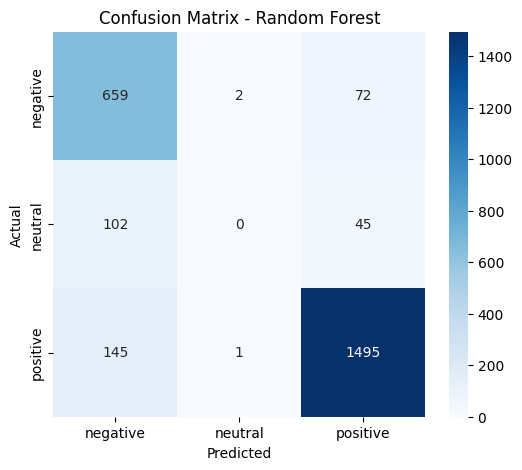

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ensure y_test is in string format to match y_pred
# if y_test contains numbers, convert them back to strings
if y_test.dtype != 'object':
    y_test_str = le.inverse_transform(y_test)
else:
    y_test_str = y_test

# pilih model terbaik (misal Random Forest)
y_pred = rf.predict(X_test_tfidf)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_str, y_pred))

# confusion matrix
cm = confusion_matrix(y_test_str, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [61]:
def predict_sentiment_ml(text):
    # Membersihkan teks menggunakan pipeline yang sudah ada
    text_clean = cleaning_pipeline(text)
    # Transformasi ke TF-IDF
    text_tfidf = tfidf.transform([text_clean])
    # Prediksi menggunakan Random Forest (rf)
    pred = rf.predict(text_tfidf)[0]
    return pred

samples = [
    "aplikasinya bagus banget dan mudah dipakai",
    "sering error dan lambat banget",
    "fiturnya biasa aja tidak terlalu membantu"
]

for s in samples:
    print(f"{s} -> {predict_sentiment_ml(s)}")

aplikasinya bagus banget dan mudah dipakai -> positive
sering error dan lambat banget -> negative
fiturnya biasa aja tidak terlalu membantu -> positive


In [66]:
# Re-inisialisasi tokenizer IndoBERT untuk memperbaiki konflik variabel
from transformers import AutoTokenizer
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def predict_sentiment_bert(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return le.inverse_transform([pred])[0]

for s in samples:
    print(s, "->", predict_sentiment_bert(s))

aplikasinya bagus banget dan mudah dipakai -> positive
sering error dan lambat banget -> negative
fiturnya biasa aja tidak terlalu membantu -> positive


In [67]:
text = "aplikasinya bagus tapi sering error"

print("ML :", predict_sentiment_ml(text))
print("BERT :", predict_sentiment_bert(text))

ML : negative
BERT : positive


In [68]:
import pandas as pd
from sklearn.metrics import accuracy_score

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_name, split_ratio):
    # training
    model.fit(X_train, y_train)

    # prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    return {
        "Algoritma": model_name,
        "Ekstraksi Fitur": feature_name,
        "Rasio Split Data": split_ratio,
        "Akurasi Training": round(train_acc * 100, 2),
        "Akurasi Testing": round(test_acc * 100, 2)
    }

## 5. Evaluasi & Kesimpulan

Bagian akhir ini merangkum performa semua model dalam sebuah tabel perbandingan untuk menentukan model mana yang paling layak digunakan dalam lingkungan produksi.

In [69]:
results = []

# Logistic Regression
results.append(
    evaluate_model(
        lr,
        X_train_tfidf, X_test_tfidf,
        y_train, y_test,
        "Logistic Regression",
        "TF-IDF",
        "80:20"
    )
)

# SVM
results.append(
    evaluate_model(
        svm,
        X_train_tfidf, X_test_tfidf,
        y_train, y_test,
        "SVM",
        "TF-IDF",
        "80:20"
    )
)

# Random Forest
results.append(
    evaluate_model(
        rf,
        X_train_tfidf, X_test_tfidf,
        y_train, y_test,
        "Random Forest",
        "TF-IDF",
        "80:20"
    )
)

In [75]:
df_results = pd.DataFrame(results)

# kasih nomor skema
df_results.insert(0, "Skema", range(1, len(df_results)+1))

bert_result = {
    "Skema": len(df_results)+1,
    "Algoritma": "IndoBERT",
    "Ekstraksi Fitur": "Transformer",
    "Rasio Split Data": "80:20",
    "Akurasi Training": 90.0,  # isi approx / dari log
    "Akurasi Testing": 86.67
}

df_results = pd.concat([df_results, pd.DataFrame([bert_result])], ignore_index=True)

df_results

,Skema,Algoritma,Ekstraksi Fitur,Rasio Split Data,Akurasi Training,Akurasi Testing
0,1,Logistic Regression,TF-IDF,80:20,93.59,85.28
1,2,SVM,TF-IDF,80:20,99.50,83.70
2,3,Random Forest,TF-IDF,80:20,99.97,85.44
3,4,IndoBERT,Transformer,80:20,90.00,86.67


In [76]:
df_results.sort_values(by="Akurasi Testing", ascending=False)

,Skema,Algoritma,Ekstraksi Fitur,Rasio Split Data,Akurasi Training,Akurasi Testing
3,4,IndoBERT,Transformer,80:20,90.00,86.67
2,3,Random Forest,TF-IDF,80:20,99.97,85.44
0,1,Logistic Regression,TF-IDF,80:20,93.59,85.28
1,2,SVM,TF-IDF,80:20,99.50,83.70


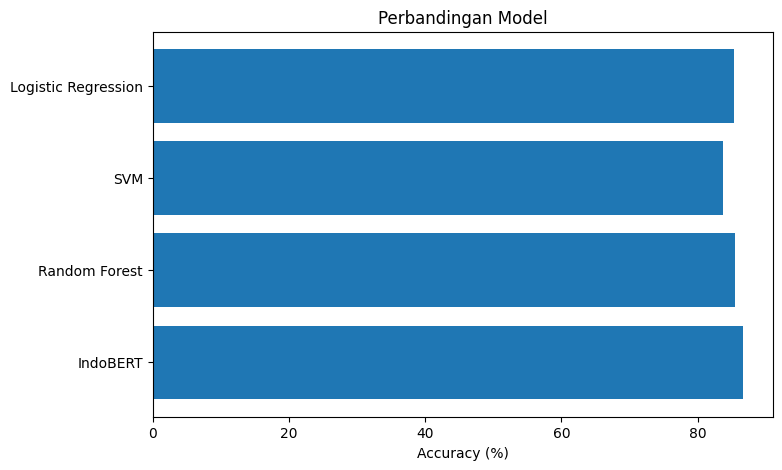

Model terbaik:
Skema                         4
Algoritma              IndoBERT
Ekstraksi Fitur     Transformer
Rasio Split Data          80:20
Akurasi Training           90.0
Akurasi Testing           86.67
Name: 3, dtype: object


In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(df_results["Algoritma"], df_results["Akurasi Testing"])
plt.xlabel("Accuracy (%)")
plt.title("Perbandingan Model")
plt.gca().invert_yaxis()
plt.show()

print("Model terbaik:")
best = df_results.loc[df_results["Akurasi Testing"].idxmax()]
print(best)